# LSTM回归分析

## $\S1$ Configuration & Data Preparation

In [3]:
# Configuration
## Loading Packages
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import shap



## Training Device: CPU or GPU（本机采用CPU）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


## Setting Random Seed
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Initial SHAP
shap.initjs()


## Data Path
DATA_PATH = "./Raw_Data_5.xlsx"
Dependent_Variable = "USD_index_Close"


## Hyper Parameters Setting
### Scaling Option
SCALE_Y = False
MULTIPLE_Y = 1000
N_EPOCHS     = 50
PATIENCE     = 8
WEIGHT_DECAY = 1e-5

### Split Ratio
TRAIN_RATIO = 0.60
VAL_RATIO   = 0.20
TEST_RATIO  = 1.0 - TRAIN_RATIO - VAL_RATIO

### Training and Testing Parameters
BATCH_SIZE_LIST  = [64, 128, 256]
LOOKBACK_LIST    = [10, 20, 40]
NUM_LAYERS_LIST  = [1, 2]
HIDDEN_SIZE_LIST = [32, 64]
DROPOUT_LIST     = [0.2, 0.4]
LR_LIST          = [5e-4, 1e-4]


Using device: cuda


In [4]:
# Data Preparation
## Loading Data
Data = pd.read_excel(DATA_PATH, index_col="日期")
print("Data Size:", Data.shape)

## Data Split & Scale
### Split Features and Label
X = Data.drop(columns=[Dependent_Variable]).values.astype(np.float32)
y = Data[[Dependent_Variable]].values.astype(np.float32) * MULTIPLE_Y

### Split Train, Valid and Test Data Sets
N = len(X)
n_train = int(N * TRAIN_RATIO)
n_val   = int(N * VAL_RATIO)
n_test  = N - n_train - n_val
print(f"训练集大小:{n_train}, 验证集大小:{n_val}, 测试集大小:{n_test}")
X_train = X[:n_train]
y_train = y[:n_train]

X_val   = X[n_train:n_train + n_val]
y_val   = y[n_train:n_train + n_val]

X_test  = X[n_train + n_val:]
y_test  = y[n_train + n_val:]

Data Size: (3456, 36)
训练集大小:2073, 验证集大小:691, 测试集大小:692


In [5]:
### Data Scale
#### We will perform sacle dring Model selection and Final training


### Constructing Data Window
def create_sequences(X, y, seq_len):
    """
    X: 2D array, shape (n_samples, n_features)
    y: 2D array, shape (n_samples, 1)
    Return:
      X_seq: (N, seq_len, n_features)
      y_seq: (N,) or (N, 1)
    """
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i + seq_len])
        y_seq.append(y[i + seq_len])
    X_seq = np.stack(X_seq)             # (N, seq_len, n_features)
    y_seq = np.stack(y_seq).squeeze()   # (N,)
    return X_seq.astype(np.float32), y_seq.astype(np.float32)

In [6]:
### DataSet and DataLoader
class FXDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def make_dataloaders(X_train_seq, y_train_seq,
                     X_val_seq=None,   y_val_seq=None,
                     X_test_seq=None,  y_test_seq=None,
                     batch_size=64):
    train_dataset = FXDataset(X_train_seq, y_train_seq)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    val_loader = None
    test_loader = None

    if X_val_seq is not None and y_val_seq is not None:
        val_dataset = FXDataset(X_val_seq, y_val_seq)
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    if X_test_seq is not None and y_test_seq is not None:
        test_dataset = FXDataset(X_test_seq, y_test_seq)
        test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader

## $\S2$ Model Selection, Training & Predicting

In [7]:
# Model Definition
class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        # x: (batch, seq_len, input_size)
        out, (h_n, c_n) = self.lstm(x)
        # out: (batch, seq_len, hidden_size)
        last_hidden = out[:, -1, :]           # (batch, hidden_size)
        y_pred = self.fc(last_hidden)         # (batch, 1)
        return y_pred.squeeze(-1)             # (batch,)

def train_model(model, train_loader, val_loader=None,
                n_epochs=50, lr=1e-3,
                weight_decay=1e-5, patience=8):
    """
    如果 val_loader is None: 表示Final Training
    如果 val_loader存在: 表示Model Selection + early stopping。
    """
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_state_dict = None
    best_val_loss = float("inf")
    wait = 0

    for epoch in range(1, n_epochs + 1):
        # ---- Train ----
        model.train()
        train_loss_sum = 0.0
        n_train_samples = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * len(X_batch)
            n_train_samples += len(X_batch)

        train_loss = train_loss_sum / n_train_samples

        if val_loader is None:
            # 没有验证集，直接打印训练损失
            print(f"Epoch {epoch:03d} | train_loss={train_loss:.6f}")
            continue

        # ---- Validation ----
        model.eval()
        val_loss_sum = 0.0
        n_val_samples = 0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                val_loss_sum += loss.item() * len(X_batch)
                n_val_samples += len(X_batch)
        val_loss = val_loss_sum / n_val_samples

        print(f"Epoch {epoch:03d} | train_loss={train_loss:.6f} | val_loss={val_loss:.6f}")

        # ---- Early Stopping ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state_dict = model.state_dict()
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch}, best_val_loss={best_val_loss:.6f}")
                break

    # 如果有验证集且保存了最佳参数，载入之
    if val_loader is not None and best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return model


In [8]:
# Model Selection
input_size = X_train.shape[1]

best_config = None
best_val_loss_overall = float("inf")

for lookback in LOOKBACK_LIST:
    print("=" * 80)
    print(f"Trying lookback = {lookback}")

    ## 针对给定lookback，先在Train上scaler，再构造Train/Val序列
    scaler_X_cv = StandardScaler()
    X_train_scaled_cv = scaler_X_cv.fit_transform(X_train)
    X_val_scaled_cv   = scaler_X_cv.transform(X_val)

    if SCALE_Y:
        scaler_y_cv = StandardScaler()
        y_train_scaled_cv = scaler_y_cv.fit_transform(y_train)
        y_val_scaled_cv   = scaler_y_cv.transform(y_val)
    else:
        y_train_scaled_cv = y_train
        y_val_scaled_cv   = y_val

    X_train_seq_cv, y_train_seq_cv = create_sequences(X_train_scaled_cv, y_train_scaled_cv, lookback)
    X_val_seq_cv,   y_val_seq_cv   = create_sequences(X_val_scaled_cv,   y_val_scaled_cv,   lookback)

    print("Train seq shape:", X_train_seq_cv.shape, y_train_seq_cv.shape)
    print("Val   seq shape:", X_val_seq_cv.shape,   y_val_seq_cv.shape)

    for hidden_size in HIDDEN_SIZE_LIST:
        for num_layers in NUM_LAYERS_LIST:
            for dropout in DROPOUT_LIST:
                for lr in LR_LIST:
                    for batch_size in BATCH_SIZE_LIST:
                        config = {
                            "lookback": lookback,
                            "hidden_size": hidden_size,
                            "num_layers": num_layers,
                            "dropout": dropout,
                            "lr": lr,
                            "batch_size": batch_size
                        }
                        print("\nConfig:", config)

                        train_loader_cv, val_loader_cv, _ = make_dataloaders(
                            X_train_seq_cv, y_train_seq_cv,
                            X_val_seq_cv,   y_val_seq_cv,
                            None, None,
                            batch_size=batch_size
                        )

                        model_cv = LSTMRegressor(
                            input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            dropout=dropout
                        )

                        model_cv = train_model(
                            model_cv, train_loader_cv, val_loader_cv,
                            n_epochs=N_EPOCHS,
                            lr=lr,
                            weight_decay=WEIGHT_DECAY,
                            patience=PATIENCE
                        )

                        # 在验证集上计算 MSE（用标准化后的 y，和 loss 一致）
                        model_cv.eval()
                        y_val_pred_list = []
                        y_val_true_list = []
                        with torch.no_grad():
                            for X_batch, y_batch in val_loader_cv:
                                X_batch = X_batch.to(device)
                                y_batch = y_batch.to(device)
                                y_pred = model_cv(X_batch)
                                y_val_pred_list.append(y_pred.cpu().numpy())
                                y_val_true_list.append(y_batch.cpu().numpy())
                        y_val_pred_scaled = np.concatenate(y_val_pred_list)
                        y_val_true_scaled = np.concatenate(y_val_true_list)
                        val_rmse = root_mean_squared_error(y_val_true_scaled, y_val_pred_scaled)

                        print(f"Validation MSE: {val_rmse:.6f}")

                        if val_rmse < best_val_loss_overall:
                            best_val_loss_overall = val_rmse
                            best_config = config.copy()

print("\nBest config (on Train/Val):", best_config)
print("Best validation MSE (scaled y):", best_val_loss_overall)

Trying lookback = 10
Train seq shape: (2063, 10, 35) (2063,)
Val   seq shape: (681, 10, 35) (681,)

Config: {'lookback': 10, 'hidden_size': 32, 'num_layers': 1, 'dropout': 0.2, 'lr': 0.0005, 'batch_size': 64}
Epoch 001 | train_loss=27.445673 | val_loss=14.570548
Epoch 002 | train_loss=27.385518 | val_loss=14.562693
Epoch 003 | train_loss=27.340608 | val_loss=14.562938
Epoch 004 | train_loss=27.301739 | val_loss=14.554988
Epoch 005 | train_loss=27.265213 | val_loss=14.555916
Epoch 006 | train_loss=27.237287 | val_loss=14.554537
Epoch 007 | train_loss=27.185013 | val_loss=14.554823
Epoch 008 | train_loss=27.147293 | val_loss=14.551456
Epoch 009 | train_loss=27.099954 | val_loss=14.556963
Epoch 010 | train_loss=27.022227 | val_loss=14.558811
Epoch 011 | train_loss=26.950893 | val_loss=14.563627
Epoch 012 | train_loss=26.877893 | val_loss=14.579617
Epoch 013 | train_loss=26.795647 | val_loss=14.602831
Epoch 014 | train_loss=26.678744 | val_loss=14.625590
Epoch 015 | train_loss=26.566743 | 

In [9]:
# Cell 8: Final Training on Train+Val and Evaluation on Test
#         + Plot Training & Test Loss Curves (per epoch)

print("\n===== Final Training with Best Config on Train+Val, then Evaluate on Test =====")

# 1) 合并 Train + Val
X_trainval = np.concatenate([X_train, X_val], axis=0)
y_trainval = np.concatenate([y_train, y_val], axis=0)

# 2) 使用 Train+Val 拟合 scaler
scaler_X_final = StandardScaler()
X_trainval_scaled = scaler_X_final.fit_transform(X_trainval)
X_test_scaled_final = scaler_X_final.transform(X_test)

if SCALE_Y:
    scaler_y_final = StandardScaler()
    y_trainval_scaled = scaler_y_final.fit_transform(y_trainval)
    y_test_scaled_final = scaler_y_final.transform(y_test)
else:
    y_trainval_scaled = y_trainval
    y_test_scaled_final = y_test

# 3) 用 best_config["lookback"] 构建序列
best_lookback = best_config["lookback"]
print("Best lookback:", best_lookback)

X_trainval_seq, y_trainval_seq = create_sequences(X_trainval_scaled, y_trainval_scaled, best_lookback)
X_test_seq_final, y_test_seq_final = create_sequences(X_test_scaled_final, y_test_scaled_final, best_lookback)

print("TrainVal seq shape:", X_trainval_seq.shape, y_trainval_seq.shape)
print("Test     seq shape:", X_test_seq_final.shape, y_test_seq_final.shape)

# 4) 用 best_config 构造 DataLoader 和 模型
final_batch_size = best_config["batch_size"]
final_lr         = best_config["lr"]
final_hidden     = best_config["hidden_size"]
final_layers     = best_config["num_layers"]
final_dropout    = best_config["dropout"]

train_loader_final, _, test_loader_final = make_dataloaders(
    X_trainval_seq, y_trainval_seq,
    None, None,                     # Final Training 不再用验证集
    X_test_seq_final, y_test_seq_final,
    batch_size=final_batch_size
)

final_model = LSTMRegressor(
    input_size = X_train.shape[1],   # 特征维度
    hidden_size = final_hidden,
    num_layers  = final_layers,
    dropout     = final_dropout
)

# 5) 定义一个“最终训练专用”的函数：每个 epoch 记录 train_loss 和 test_loss
def train_final_model_with_curves(model, train_loader, test_loader,
                                  n_epochs=50, lr=1e-3, weight_decay=1e-5):
    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses = []
    test_losses  = []

    for epoch in range(1, n_epochs + 1):
        # ---- Train (on Train+Val) ----
        model.train()
        train_loss_sum = 0.0
        n_train_samples = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            loss.backward()
            optimizer.step()

            train_loss_sum += loss.item() * len(X_batch)
            n_train_samples += len(X_batch)

        train_loss_epoch = train_loss_sum / n_train_samples

        # ---- Evaluate on Test (仅用于画曲线，不做早停/调参) ----
        model.eval()
        test_loss_sum = 0.0
        n_test_samples = 0
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                test_loss_sum += loss.item() * len(X_batch)
                n_test_samples += len(X_batch)

        test_loss_epoch = test_loss_sum / n_test_samples

        train_losses.append(train_loss_epoch)
        test_losses.append(test_loss_epoch)

        print(f"Epoch {epoch:03d} | train_loss={train_loss_epoch:.6f} | test_loss={test_loss_epoch:.6f}")

    return model, train_losses, test_losses

# 6) 运行最终训练，得到损失曲线
final_model, train_losses, test_losses = train_final_model_with_curves(
    final_model,
    train_loader_final,
    test_loader_final,
    n_epochs = N_EPOCHS,
    lr       = final_lr,
    weight_decay = WEIGHT_DECAY
)

# 7) 在 Test 集上做预测（再算一次，以便后面反标准化和指标）
final_model.eval()
y_true_scaled_list = []
y_pred_scaled_list = []

with torch.no_grad():
    for X_batch, y_batch in test_loader_final:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        y_pred = final_model(X_batch)

        y_true_scaled_list.append(y_batch.cpu().numpy())
        y_pred_scaled_list.append(y_pred.cpu().numpy())

y_true_scaled = np.concatenate(y_true_scaled_list)   # (N_test_seq,)
y_pred_scaled = np.concatenate(y_pred_scaled_list)   # (N_test_seq,)

# 反标准化回原始尺度
if SCALE_Y:
    y_true = scaler_y_final.inverse_transform(y_true_scaled.reshape(-1, 1)).ravel()
    y_pred = scaler_y_final.inverse_transform(y_pred_scaled.reshape(-1, 1)).ravel()
else:
    y_true = y_true_scaled
    y_pred = y_pred_scaled



===== Final Training with Best Config on Train+Val, then Evaluate on Test =====
Best lookback: 20
TrainVal seq shape: (2744, 20, 35) (2744,)
Test     seq shape: (672, 20, 35) (672,)
Epoch 001 | train_loss=24.150368 | test_loss=21.441146
Epoch 002 | train_loss=24.144036 | test_loss=21.438107
Epoch 003 | train_loss=24.139681 | test_loss=21.436428
Epoch 004 | train_loss=24.135054 | test_loss=21.434642
Epoch 005 | train_loss=24.131067 | test_loss=21.432665
Epoch 006 | train_loss=24.127119 | test_loss=21.431077
Epoch 007 | train_loss=24.123623 | test_loss=21.429560
Epoch 008 | train_loss=24.119915 | test_loss=21.428320
Epoch 009 | train_loss=24.116463 | test_loss=21.427631
Epoch 010 | train_loss=24.113066 | test_loss=21.426763
Epoch 011 | train_loss=24.109804 | test_loss=21.426197
Epoch 012 | train_loss=24.106381 | test_loss=21.425932
Epoch 013 | train_loss=24.103447 | test_loss=21.425641
Epoch 014 | train_loss=24.100220 | test_loss=21.425215
Epoch 015 | train_loss=24.097090 | test_loss=21

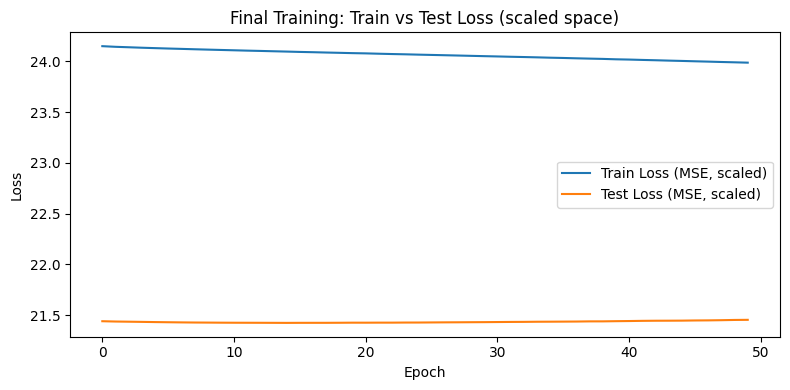

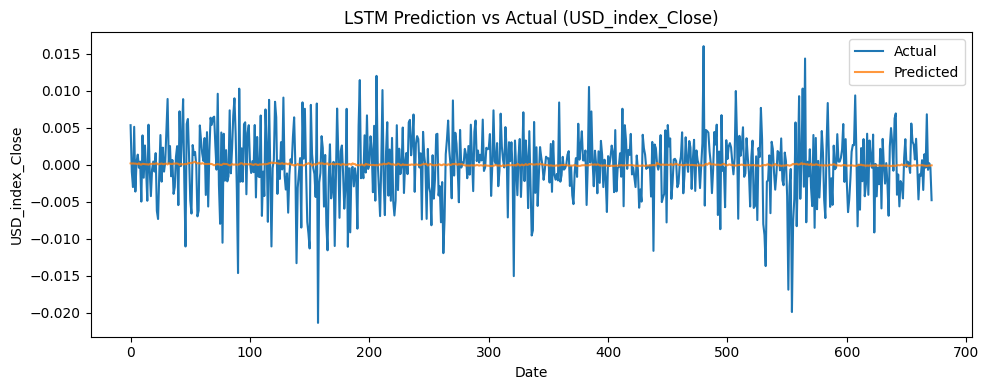


===== Test Performance (Final Model, Train+Val refit) =====
RMSE: 0.004632
MAE : 0.003490
R^2 : -0.004451
Direction Accuracy (price change sign): 0.4873


In [10]:
# 9) 画出训练 & 测试损失曲线（注意这一段的损失是在“标准化后”的尺度上）
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss (MSE, scaled)")
plt.plot(test_losses,  label="Test Loss (MSE, scaled)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Final Training: Train vs Test Loss (scaled space)")
plt.legend()
plt.tight_layout()
plt.show()

## 预测绘图
y_true = y_true/MULTIPLE_Y
y_pred = y_pred/MULTIPLE_Y
plt.figure(figsize=(10, 4))
plt.plot(y_true, label="Actual")
plt.plot(y_pred, label="Predicted", alpha=0.8)
plt.title(f"LSTM Prediction vs Actual ({Dependent_Variable})")
plt.xlabel(f"Date")
plt.ylabel(Dependent_Variable)
plt.legend()
plt.tight_layout()
plt.show()

# 8) 计算 Test 上的各种评价指标（原始尺度）
rmse  = root_mean_squared_error(y_true, y_pred)
mae  = mean_absolute_error(y_true, y_pred)
r2   = r2_score(y_true, y_pred)

print("\n===== Test Performance (Final Model, Train+Val refit) =====")
print(f"RMSE: {rmse:.6f}")
print(f"MAE : {mae:.6f}")
print(f"R^2 : {r2:.6f}")

# 如果以后把目标换成“收益”，下面这个方向准确率会更有意义
sign_true = np.sign(np.diff(y_true))
sign_pred = np.sign(np.diff(y_pred))
if len(sign_true) == len(sign_pred) and len(sign_true) > 0:
    direction_acc = (sign_true == sign_pred).mean()
    print(f"Direction Accuracy (price change sign): {direction_acc:.4f}")